In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

## Importing the data

In [45]:
DATA_PATH = '../Data/ml-1m/'
MOVIES_FILE_PATH = DATA_PATH + 'movies.dat'
RATINGS_FILE_PATH = DATA_PATH + 'ratings.dat'
USERS_FILE_PATH = DATA_PATH + 'users.dat'

movies_dataframe = pd.read_table(MOVIES_FILE_PATH, delimiter='::', header=None, engine='python')
movies_dataframe.columns = ['MovieID', 'MovieName', 'Genres']

users_dataframe = pd.read_table(USERS_FILE_PATH, delimiter='::', header=None, engine='python')
users_dataframe.columns = ['UserID','Gender', 'Age', 'Occupation', 'ZipCode']

rating_dataframe = pd.read_table(RATINGS_FILE_PATH, delimiter='::', header=None, engine='python')
rating_dataframe.columns = ['UserID','MovieID', 'Rating', 'Timestamp']

In [46]:
Genres = movies_dataframe['Genres']
Genres = Genres.str.get_dummies().add_prefix('Genres_')
movies_dataframe_dummies = pd.concat(
    [movies_dataframe.drop(
        ['Genres'],
        axis=1
    ),
     Genres],
    axis=1
)
movies_dataframe_dummies.head()

,MovieID,MovieName,Genres_Action,Genres_Adventure,Genres_Animation,Genres_Children's,Genres_Comedy,Genres_Crime,Genres_Documentary,Genres_Drama,Genres_Fantasy,Genres_Film-Noir,Genres_Horror,Genres_Musical,Genres_Mystery,Genres_Romance,Genres_Sci-Fi,Genres_Thriller,Genres_War,Genres_Western
0,1,Toy Story (1995),0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2,Jumanji (1995),0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2,3,Grumpier Old Men (1995),0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
3,4,Waiting to Exhale (1995),0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
4,5,Father of the Bride Part II (1995),0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


## Samples

In [47]:
users_dataframe

,UserID,Gender,Age,Occupation,ZipCode
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455
...,...,...,...,...,...
6035,6036,F,25,15,32603
6036,6037,F,45,1,76006
6037,6038,F,56,1,14706
6038,6039,F,45,0,01060


In [48]:
rating_dataframe

,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291
...,...,...,...,...
1000204,6040,1091,1,956716541
1000205,6040,1094,5,956704887
1000206,6040,562,5,956704746
1000207,6040,1096,4,956715648


In [49]:
movies_dataframe

,MovieID,MovieName,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
3878,3948,Meet the Parents (2000),Comedy
3879,3949,Requiem for a Dream (2000),Drama
3880,3950,Tigerland (2000),Drama
3881,3951,Two Family House (2000),Drama


## Data Analysis

Text(0.5, 1.0, 'Count Plot of Ratings')

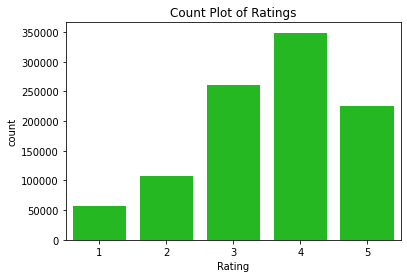

In [50]:
sns.countplot(data=rating_dataframe, x='Rating', color='#0DD10A')
plt.title('Count Plot of Ratings')

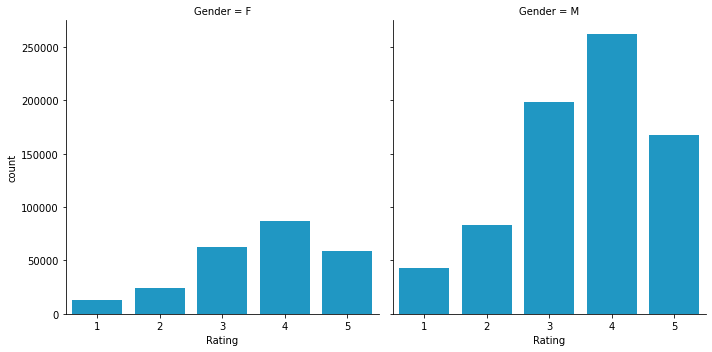

In [51]:
sns.catplot(data=rating_dataframe.join(users_dataframe.set_index('UserID'), how='inner', on='UserID') , x='Rating', col='Gender', kind='count', color='#05A3DE')

Text(0.5, 1.0, 'Count Plot of Age Label')

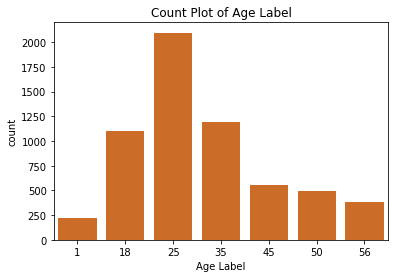

In [52]:
sns.countplot(data=users_dataframe, x='Age', color='#E7670E')
plt.xlabel('Age Label')
plt.title('Count Plot of Age Label')

Text(0.5, 1.0, 'Count Plot of Occupation')

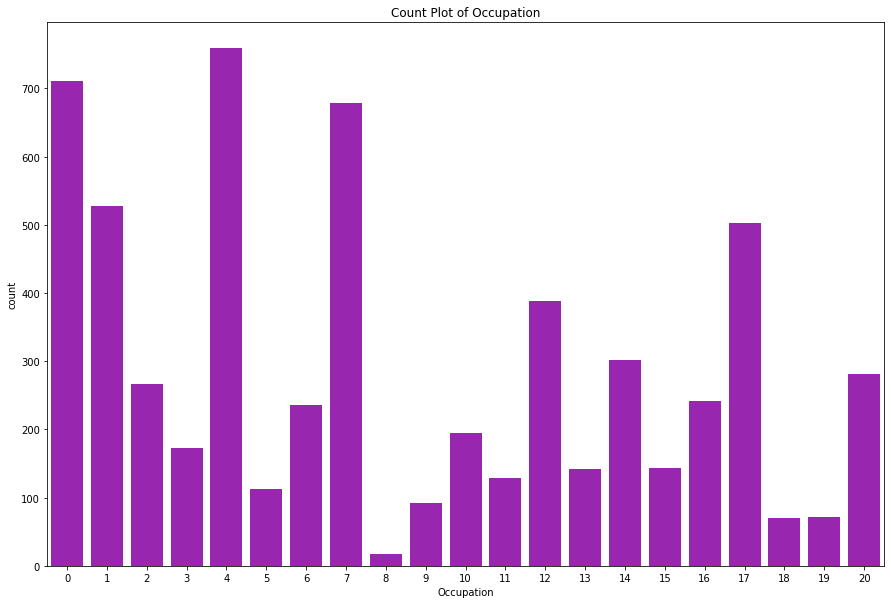

In [53]:
plt.figure(figsize=(15,10))
sns.countplot(data=users_dataframe, x='Occupation', color='#A70FC5')
plt.title('Count Plot of Occupation')

In [54]:
rating_dataframe.groupby('MovieID')[['Rating']].aggregate('mean').sort_values(by='Rating', ascending=False).iloc[:10]

,Rating
MovieID,
989,5.0
3881,5.0
1830,5.0
3382,5.0
787,5.0
3280,5.0
3607,5.0
3233,5.0
3172,5.0


Text(0.5, 1.0, 'Count Plot of Genres')

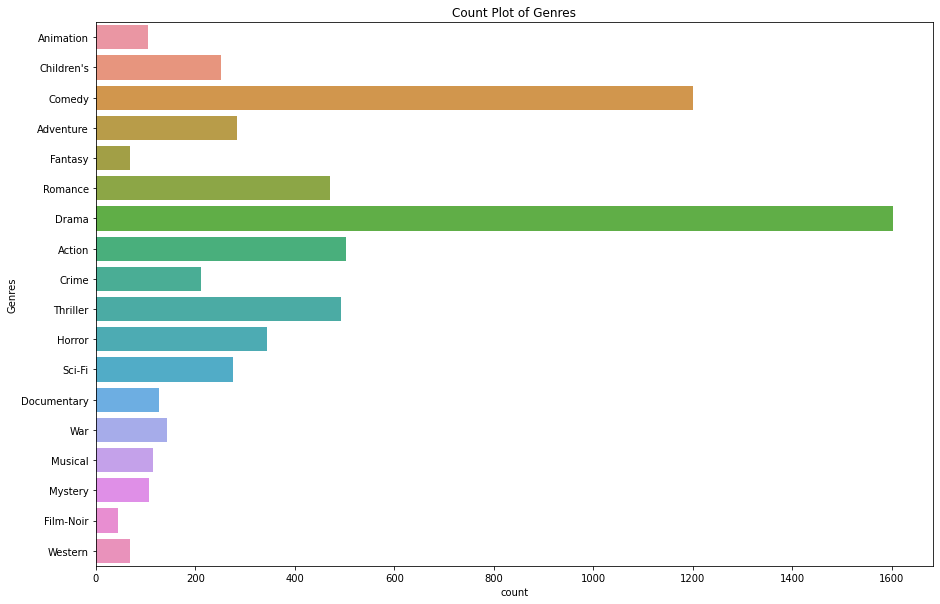

In [55]:
movies_dataframe['Genres'] = movies_dataframe['Genres'].apply(lambda x: x.split('|'))
movies_dataframe_exploded = movies_dataframe.explode('Genres')
plt.figure(figsize=(15,10))
sns.countplot(data=movies_dataframe_exploded, y='Genres')
plt.title('Count Plot of Genres')

In [56]:
movies_dataframe_exploded

,MovieID,MovieName,Genres
0,1,Toy Story (1995),Animation
0,1,Toy Story (1995),Children's
0,1,Toy Story (1995),Comedy
1,2,Jumanji (1995),Adventure
1,2,Jumanji (1995),Children's
...,...,...,...
3879,3949,Requiem for a Dream (2000),Drama
3880,3950,Tigerland (2000),Drama
3881,3951,Two Family House (2000),Drama
3882,3952,"Contender, The (2000)",Drama


c:\Dev\Python\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


Text(0.5, 1.0, 'Dist plot of Year Feature')

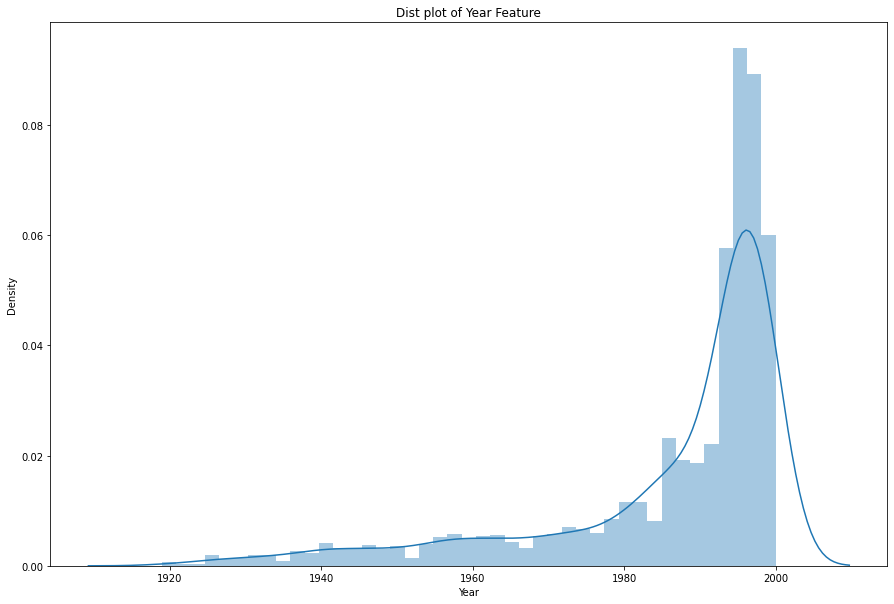

In [57]:
movies_dataframe['Year'] = movies_dataframe['MovieName'].apply(lambda movie_name: re.search('\(\d+\)', movie_name)[0][1:-1])
plt.figure(figsize=(15,10))
sns.distplot(movies_dataframe['Year'])
plt.title('Dist plot of Year Feature')